# Task 3 - Step 2: Source-side diagnostics and freezing all Task 3 decisions

**No Sketch image or label is used in this notebook.**

1. Accuracy and macro-F1 on each source validation domain, their mean and worst, for every model.
2. Training curves: classification loss, source-validation macro-F1, the DAN-DG MMD penalty (mean and per pair),
   and SAM's perturbed-minus-clean loss.
3. **Source-domain separability**: 512-d features of the three source validation sets, balanced to the smallest
   (seed 6304), stratified 70/30 split, multinomial logistic regression (C = 1). Held-out accuracy; chance = 1/3.
4. **Sharpness proxy** on the fixed batch from notebook 00 (32 per source, eval mode, one normalised ascent step of
   radius 0.05): Δ = L(θ+ε) − L(θ).
5. A **freeze manifest** (SHA-256 of every checkpoint, config and summary, the split and the sharpness batch).
   Notebook 03 may load Sketch only if these files are unchanged.

In [1]:
# ---- Task 3 common header (identical in every Task 3 notebook) ----
# NOTE: this header never loads any Sketch image or label. Only notebook 03 does, after the freeze check.
import json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve()
while not (REPO / "shared" / "pacs.py").exists():
    if REPO.parent == REPO:
        raise RuntimeError("Run this notebook from inside the PA1 repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from shared import pacs, pacs_protocol as proto
from shared.config import load_config

T3 = REPO / "task3"
CFG_DIR = T3 / "configs"
EVAL_CFG = __import__("yaml").safe_load((CFG_DIR / "evaluation.yaml").read_text())
SEED = 6304
# Smoke mode (env TASK3_SMOKE=1): 2 epochs x 5 updates per trained run, outputs under _smoke/, and notebook 03 uses
# RANDOM stand-in images and labels, so no Sketch image or label is touched.
SMOKE = os.environ.get("TASK3_SMOKE", "0") == "1"
SUB = "_smoke" if SMOKE else ""
RES = T3 / "results" / SUB
TAB, FIG = RES / "tables", RES / "figures"
DATA_TAB = T3 / "results" / "tables"      # protocol/data-prep files from notebook 00 (same in smoke and real mode)
DATA_TAB.mkdir(parents=True, exist_ok=True)
CKPT = T3 / "checkpoints" / SUB            # git-ignored
CACHE = T3 / "cache" / SUB                 # git-ignored
for p in [TAB, FIG, CKPT, CACHE]:
    p.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ERM_DIR = REPO / "task2" / "checkpoints" / "source_only"      # ERM = Task 2 Source-only, loaded, never retrained
TRAIN_RUNS = ["dan_dg", "sam", "dan_dg_lambda0.1", "dan_dg_lambda10"]
MAIN_RUNS = ["erm", "dan_dg", "sam"]
STUDY_RUNS = ["dan_dg_lambda0.1", "dan_dg", "dan_dg_lambda10"]    # controlled study: lambda_DG in {0.1, 1, 10}
ALL_RUNS = ["erm", "dan_dg", "sam", "dan_dg_lambda0.1", "dan_dg_lambda10"]
RUN_NAME = {c: load_config(CFG_DIR, c)["run_name"] for c in ALL_RUNS}
LABEL = {"erm": "ERM", "dan_dg": "DAN-DG (λ=1)", "sam": "SAM (ρ=0.05)",
         "dan_dg_lambda0.1": "DAN-DG (λ=0.1)", "dan_dg_lambda10": "DAN-DG (λ=10)"}


def run_dir(n):
    return ERM_DIR if n == "erm" else CKPT / RUN_NAME[n]


def load_trained(n):
    """Model with the selected checkpoint of run ``n`` (ERM: the Task 2 Source-only checkpoint)."""
    from shared.models import build_model
    ck = torch.load(run_dir(n) / "best.pt", map_location="cpu", weights_only=False)
    model = build_model(7, SEED)
    model.load_state_dict(ck["model"])
    return model.to(DEVICE).eval(), ck


plt.rcParams.update({"font.size": 11, "axes.titlesize": 12, "legend.fontsize": 9, "savefig.dpi": 150})


def savefig(fig, stem):
    fig.savefig(FIG / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")
    print("saved figure", stem)


print("REPO:", REPO, "| device:", DEVICE, "| smoke:", SMOKE)

REPO: C:\Users\afifh\Desktop\ATML\PA1 | device: cuda | smoke: False


In [2]:
from shared.evaluation import domain_separability, evaluate_sources, predict, sharpness_proxy

SUMM, HIST = {}, {}
for n in ALL_RUNS:
    d = run_dir(n)
    assert (d / "summary.json").exists(), f"run {n} missing - run notebook 01 first"
    SUMM[n], HIST[n] = json.loads((d / "summary.json").read_text()), json.loads((d / "history.json").read_text())
source = proto.load_source_data()
CLASSES = pacs.class_names()

## 2.1 Source validation per domain (re-evaluated from the selected checkpoints)

In [3]:
rows, SRC_EVAL = [], {}
for n in ALL_RUNS:
    model, ck = load_trained(n)
    v = evaluate_sources(model, source["val"], DEVICE)
    SRC_EVAL[n] = v
    diff = abs(v["mean_macro_f1"] - SUMM[n]["best_mean_val_macro_f1"])
    if diff > 1e-3:
        print(f"WARNING {n}: re-evaluated mean F1 differs from the training-time value by {diff:.4f}")
    row = {"config": n, "method": LABEL[n], "best_epoch": ck["epoch"], "reeval_vs_training_mean_f1_diff": diff}
    for dom in pacs.SOURCE_DOMAINS:
        row[f"{dom}_acc"], row[f"{dom}_macro_f1"] = v["domains"][dom]["acc"], v["domains"][dom]["macro_f1"]
    row.update(mean_acc=v["mean_acc"], mean_macro_f1=v["mean_macro_f1"], worst_acc=v["worst_acc"], worst_macro_f1=v["worst_macro_f1"],
               worst_domain_by_acc=min(v["domains"], key=lambda d: v["domains"][d]["acc"]))
    rows.append(row)
    del model
SRC = pd.DataFrame(rows)
SRC.to_csv(TAB / "task3_source_validation.csv", index=False)
SRC.round(4)

,config,method,best_epoch,reeval_vs_training_mean_f1_diff,photo_acc,photo_macro_f1,art_painting_acc,art_painting_macro_f1,cartoon_acc,cartoon_macro_f1,mean_acc,mean_macro_f1,worst_acc,worst_macro_f1,worst_domain_by_acc
0,erm,ERM,6,0.0,0.9551,0.9459,0.9073,0.9040,0.9403,0.9452,0.9342,0.9317,0.9073,0.9040,art_painting
1,dan_dg,DAN-DG (λ=1),1,0.0,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.0507,0.1727,0.0421,cartoon
2,sam,SAM (ρ=0.05),5,0.0,0.9760,0.9723,0.9390,0.9387,0.9574,0.9623,0.9575,0.9578,0.9390,0.9387,art_painting
3,dan_dg_lambda0.1,DAN-DG (λ=0.1),5,0.0,0.9731,0.9692,0.9366,0.9399,0.9488,0.9535,0.9528,0.9542,0.9366,0.9399,art_painting
4,dan_dg_lambda10,DAN-DG (λ=10),1,0.0,0.2575,0.0585,0.2195,0.0514,0.1727,0.0421,0.2166,0.0507,0.1727,0.0421,cartoon


## 2.2 Training curves (classification loss, source-val F1, MMD penalty, SAM gap)

saved figure task3_training_curves


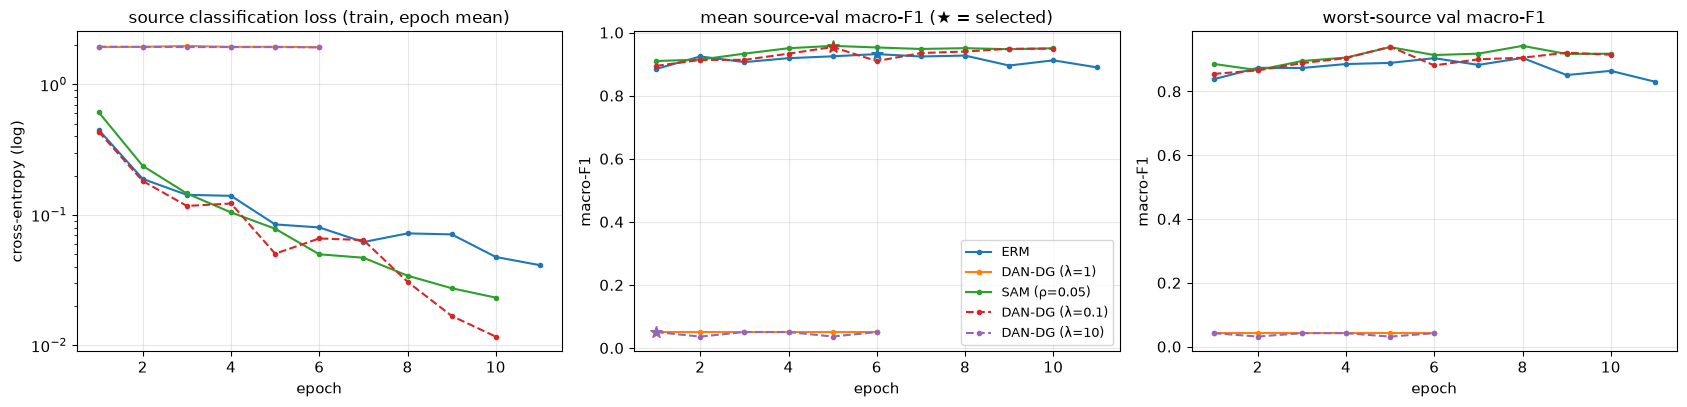

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for n in ALL_RUNS:
    ep = [h["epoch"] for h in HIST[n]]
    ls = "--" if n in ("dan_dg_lambda0.1", "dan_dg_lambda10") else "-"
    axes[0].plot(ep, [h["train"]["cls_loss"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
    axes[1].plot(ep, [h["val"]["mean_macro_f1"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
    axes[2].plot(ep, [h["val"]["worst_macro_f1"] for h in HIST[n]], ls, marker=".", label=LABEL[n])
    axes[1].scatter([SUMM[n]["best_epoch"]], [SUMM[n]["best_mean_val_macro_f1"]], marker="*", s=70, zorder=5)
axes[0].set_yscale("log")
for ax, t, yl in [(axes[0], "source classification loss (train, epoch mean)", "cross-entropy (log)"),
                  (axes[1], "mean source-val macro-F1 (★ = selected)", "macro-F1"),
                  (axes[2], "worst-source val macro-F1", "macro-F1")]:
    ax.set_title(t); ax.set_xlabel("epoch"); ax.set_ylabel(yl); ax.grid(alpha=.3)
axes[1].legend()
plt.tight_layout(); savefig(fig, "task3_training_curves"); plt.show()

saved figure task3_mmd_penalty


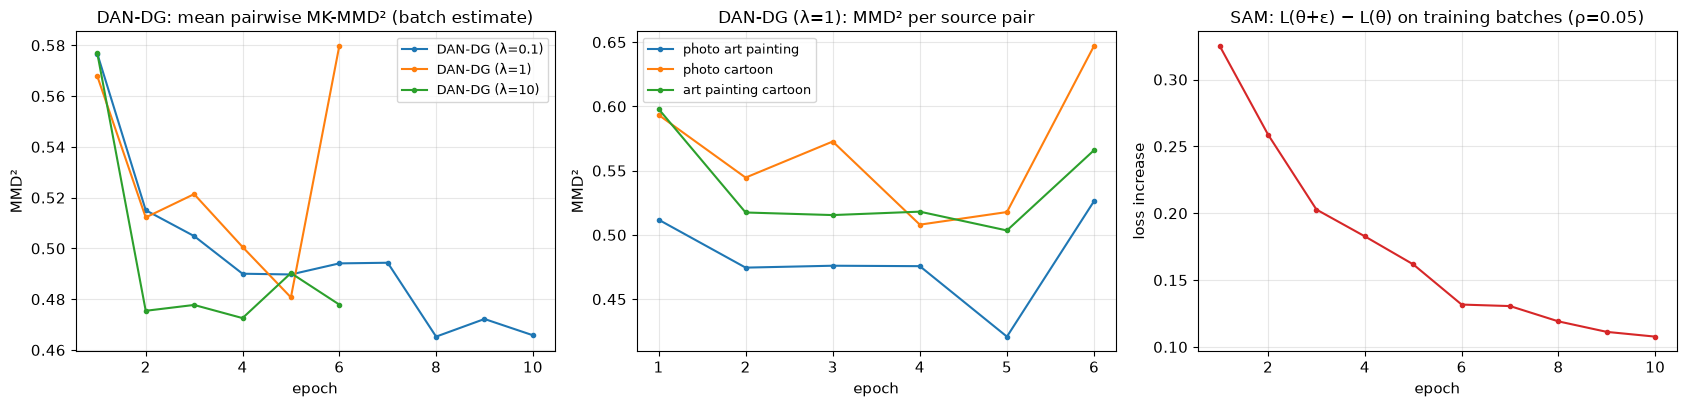

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
for n in STUDY_RUNS:
    ep = [h["epoch"] for h in HIST[n]]
    axes[0].plot(ep, [h["train"]["mmd"] for h in HIST[n]], marker=".", label=LABEL[n])
for key in [k for k in HIST["dan_dg"][0]["train"] if k.startswith("mmd_")]:
    axes[1].plot([h["epoch"] for h in HIST["dan_dg"]], [h["train"][key] for h in HIST["dan_dg"]], marker=".", label=key[4:].replace("_", " "))
axes[2].plot([h["epoch"] for h in HIST["sam"]], [h["train"]["sam_gap"] for h in HIST["sam"]], marker=".", color="tab:red")
axes[0].set_title("DAN-DG: mean pairwise MK-MMD² (batch estimate)"); axes[0].set_ylabel("MMD²")
axes[1].set_title("DAN-DG (λ=1): MMD² per source pair"); axes[1].set_ylabel("MMD²")
axes[2].set_title("SAM: L(θ+ε) − L(θ) on training batches (ρ=0.05)"); axes[2].set_ylabel("loss increase")
for ax in axes:
    ax.set_xlabel("epoch"); ax.grid(alpha=.3)
axes[0].legend(); axes[1].legend()
plt.tight_layout(); savefig(fig, "task3_mmd_penalty"); plt.show()

## 2.3 Source-domain separability (3-way, chance = 1/3) and 2.4 sharpness proxy

In [6]:
sb = json.loads((DATA_TAB / "task3_sharpness_batch.json").read_text())
xb = torch.cat([source["val"][d][0][torch.as_tensor(sb["indices_into_source_val"][d])] for d in pacs.SOURCE_DOMAINS])
yb = torch.cat([source["val"][d][1][torch.as_tensor(sb["indices_into_source_val"][d])] for d in pacs.SOURCE_DOMAINS])
sep_cfg = EVAL_CFG["source_domain_separability"]
SEP, SHARP = {}, {}
for n in ALL_RUNS:
    model, _ = load_trained(n)
    feats = {d: predict(model, source["val"][d][0], DEVICE)[0].numpy() for d in pacs.SOURCE_DOMAINS}
    SEP[n] = domain_separability(feats, seed=SEED, test_size=sep_cfg["test_size"], C=sep_cfg["C"])
    SHARP[n] = sharpness_proxy(model, xb, yb, DEVICE, radius=sb["radius"])
    print(f"{n:17s} separability {SEP[n]['separability_acc']:.4f} | Δsharp {SHARP[n]['delta_sharp']:.4f} "
          f"(L {SHARP[n]['loss']:.4f} -> {SHARP[n]['loss_perturbed']:.4f}, |g| {SHARP[n]['grad_norm']:.3f})")
    del model
pd.DataFrame([{"config": n, "method": LABEL[n], **{k: v for k, v in SEP[n].items() if k != "test_confusion"},
               "test_confusion": json.dumps(SEP[n]["test_confusion"])} for n in ALL_RUNS]).to_csv(TAB / "task3_domain_separability.csv", index=False)
pd.DataFrame([{"config": n, "method": LABEL[n], **SHARP[n]} for n in ALL_RUNS]).to_csv(TAB / "task3_sharpness.csv", index=False)

erm               separability 0.8870 | Δsharp 0.2839 (L 0.1323 -> 0.4162, |g| 4.951)


dan_dg            separability 0.3322 | Δsharp 0.0097 (L 1.9354 -> 1.9451, |g| 1.064)


sam               separability 0.8904 | Δsharp 0.0812 (L 0.0720 -> 0.1532, |g| 1.277)


dan_dg_lambda0.1  separability 0.8140 | Δsharp 0.2761 (L 0.0851 -> 0.3612, |g| 3.452)


dan_dg_lambda10   separability 0.3821 | Δsharp 0.0078 (L 1.9349 -> 1.9427, |g| 0.931)


saved figure task3_sharpness_comparison


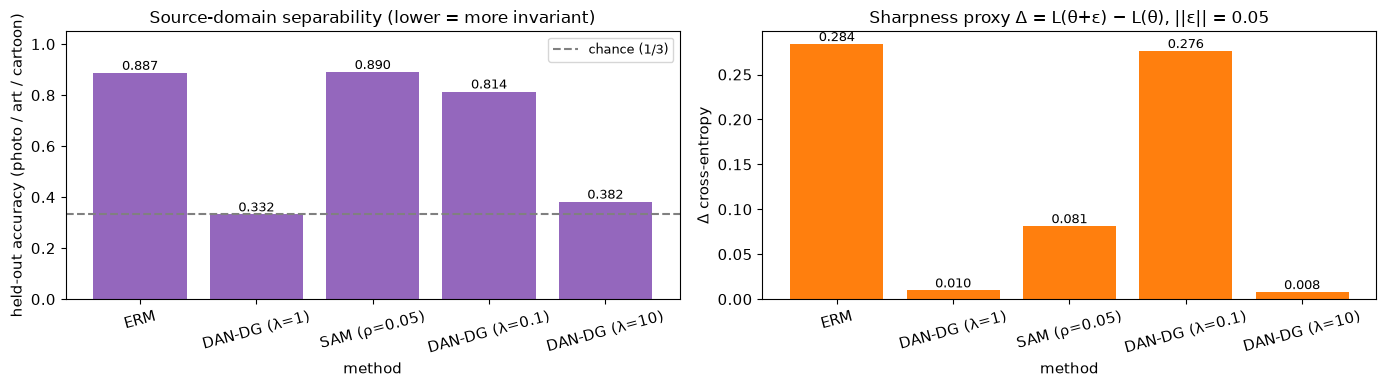

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
names = [LABEL[n] for n in ALL_RUNS]
axes[0].bar(names, [SEP[n]["separability_acc"] for n in ALL_RUNS], color="tab:purple")
axes[0].axhline(1 / 3, ls="--", color="gray", label="chance (1/3)")
axes[0].set_ylabel("held-out accuracy (photo / art / cartoon)"); axes[0].set_title("Source-domain separability (lower = more invariant)")
axes[0].set_ylim(0, 1.05); axes[0].legend()
axes[1].bar(names, [SHARP[n]["delta_sharp"] for n in ALL_RUNS], color="tab:orange")
axes[1].set_ylabel("Δ cross-entropy"); axes[1].set_title("Sharpness proxy Δ = L(θ+ε) − L(θ), ||ε|| = 0.05")
for ax, vals in [(axes[0], [SEP[n]["separability_acc"] for n in ALL_RUNS]), (axes[1], [SHARP[n]["delta_sharp"] for n in ALL_RUNS])]:
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15); ax.set_xlabel("method")
plt.tight_layout(); savefig(fig, "task3_sharpness_comparison"); plt.show()

## 2.5 Freeze manifest (after this, Task 3 decisions are fixed)

In [8]:
frozen = [proto.SPLIT_PATH, DATA_TAB / "task3_sharpness_batch.json"]
frozen += sorted(CFG_DIR.glob("*.yaml"))
for n in ALL_RUNS:
    frozen += [run_dir(n) / f for f in ("best.pt", "config.yaml", "summary.json")]
manifest = pacs.write_freeze_manifest(CACHE / "freeze_manifest.json", frozen,
                                      note="Task 3: all runs trained and selected on source validation; source-side diagnostics done; no Sketch accessed")
print("frozen files:", len(manifest["files"]), "|", manifest["created"])

frozen files: 24 | 2026-09-22 18:45:44
